# Module 5, Class 4: PCA, t-SNE, and UMAP

**Student:** Firdavs Boliev

This notebook compares three 2D visualization methods for customer clusters.


## 0. Setup

In [1]:
# Import data, clustering, and dimensionality reduction tools.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import umap
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## 1. Load and Standardize Data

In [2]:
# Load Mall Customers data, using a deterministic fallback if the public URL is unavailable.
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/Mall_Customers.csv"

try:
    df = pd.read_csv(url)
    print("Loaded Mall Customers from the public URL.")
except Exception:
    print("Public Mall Customers URL unavailable. Generating a small Mall-like dataset.")
    rng = np.random.default_rng(42)
    segments = [
        ("Male", 24, 30, 75, 40),
        ("Female", 26, 32, 80, 40),
        ("Male", 52, 85, 22, 40),
        ("Female", 45, 82, 28, 40),
        ("Female", 39, 60, 50, 40),
    ]
    rows = []
    for gender, age_mean, income_mean, spend_mean, n in segments:
        for _ in range(n):
            rows.append({
                "CustomerID": len(rows) + 1,
                "Gender": gender if rng.random() < 0.75 else ("Female" if gender == "Male" else "Male"),
                "Age": int(np.clip(rng.normal(age_mean, 6), 18, 70)),
                "Annual Income (k$)": int(np.clip(rng.normal(income_mean, 10), 15, 140)),
                "Spending Score (1-100)": int(np.clip(rng.normal(spend_mean, 12), 1, 100)),
            })
    df = pd.DataFrame(rows)

df['Gender_encoded'] = (df['Gender'] == 'Male').astype(int)
features = ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Features: {features}")


Public Mall Customers URL unavailable. Generating a small Mall-like dataset.
Shape: (200, 4)
Features: ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


## 2. K-Means Cluster Labels (for coloring)

In [3]:
# Create K-Means labels so the 2D plots can be colored by cluster.
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())


Cluster distribution:
0    42
1    34
2    42
3    40
4    42
Name: count, dtype: int64


## 3. PCA to 2D

In [4]:
# Project the scaled features into two dimensions with PCA.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")


PCA explained variance: 89.6%


## 4. t-SNE to 2D

In [5]:
# Project the scaled features into two dimensions with t-SNE.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

print(f"t-SNE complete. KL divergence: {tsne.kl_divergence_:.4f}")


t-SNE complete. KL divergence: 0.1806


## 5. UMAP to 2D

In [6]:
# Project the scaled features into two dimensions with UMAP.
reducer = umap.UMAP(n_components=2, n_neighbors=15, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

print("UMAP complete.")


UMAP complete.


## 6. Side-by-Side Comparison

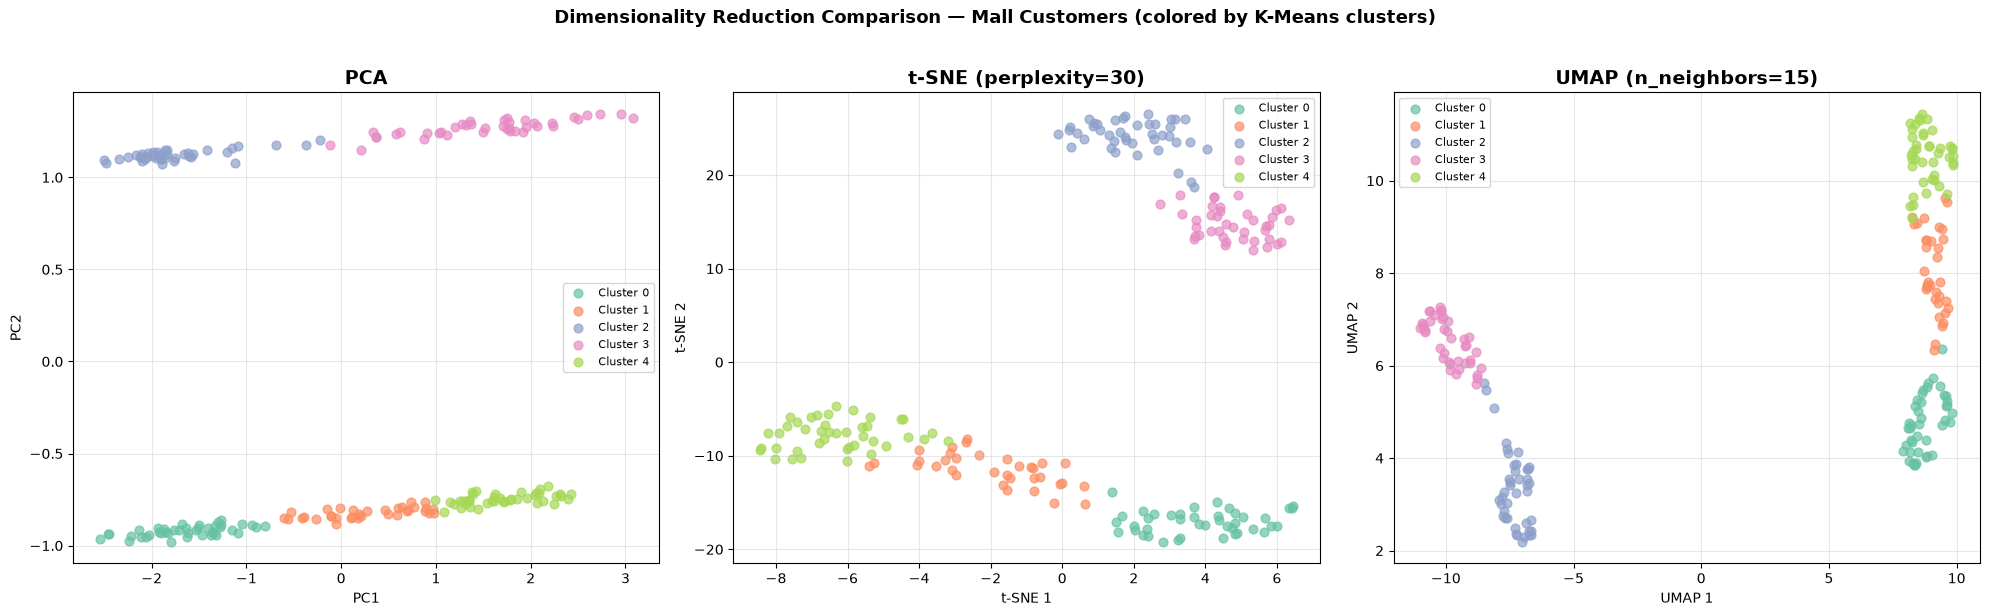

In [7]:
# Compare PCA, t-SNE, and UMAP plots side by side.
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
palette = sns.color_palette('Set2', 5)

# PCA
for c in range(5):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=40)
axes[0].set_title('PCA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# t-SNE
for c in range(5):
    mask = cluster_labels == c
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=40)
axes[1].set_title('t-SNE (perplexity=30)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# UMAP
for c in range(5):
    mask = cluster_labels == c
    axes[2].scatter(X_umap[mask, 0], X_umap[mask, 1], c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=40)
axes[2].set_title('UMAP (n_neighbors=15)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Dimensionality Reduction Comparison — Mall Customers (colored by K-Means clusters)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Quick Reference: PCA vs t-SNE vs UMAP

| Method | Type | Preserves | Speed | Axes Interpretable? |
|--------|------|-----------|-------|--------------------|
| PCA | Linear | Global variance | Fast | Yes (loadings) |
| t-SNE | Non-linear | Local neighborhoods | Slow | No |
| UMAP | Non-linear | Local + global structure | Medium | No |

## 7. Which Visualization Best Reveals Cluster Structure?

Look at the 3 plots above and answer:

1. Which method produces the most visually separated clusters?
2. Why does PCA sometimes fail to separate clusters that t-SNE/UMAP can?
3. Would you use t-SNE or UMAP for a dataset with 1 million rows? Why?
4. Why should you NOT interpret distances in t-SNE plots the same way as in PCA plots?

### Visualization Answer

UMAP and t-SNE show the cluster structure more clearly than PCA because they can capture non-linear patterns. PCA is useful and fast, but it only makes a linear projection, so curved or more complex groups can overlap.

For a dataset with 1 million rows, I would prefer UMAP over t-SNE because UMAP usually scales better. I would not interpret distances in a t-SNE plot like PCA distances, because t-SNE focuses on preserving local neighborhoods and can distort global spacing between groups.


---
## Summary

| Concept | Details |
|---------|--------|
| PCA | Linear projection onto max-variance directions. Fast, interpretable, but misses non-linear structure |
| t-SNE | Preserves local neighborhoods via probability distributions. Good for visualization, slow on large data |
| UMAP | Topological approach — preserves local AND global structure. Faster than t-SNE, scales better |
| perplexity (t-SNE) | Controls neighborhood size. Typical range: 5-50 |
| n_neighbors (UMAP) | Controls local vs global balance. Low = local detail, high = global structure |
| Key rule | t-SNE/UMAP are for visualization only — do not use the 2D output for clustering or modeling |